#  >>>>>>  End-to-End House Price Prediction using Machine Learning <<<<<<    



## OBJECTIVE : 

#### The objective of this project is to build a machine learning model that can predict house sale prices based on property characteristics such as plot size, construction year, basement area, and location-related features. The project focuses on end-to-end implementation including data preprocessing, exploratory data analysis, feature engineering, model building, evaluation, and final model selection.

 ## 1. IMPORT REQUIRED LIBRARIES


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,mean_absolute_percentage_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR


## 2. DATA LOADING

In [3]:
data = pd.read_excel(r"C:\Users\ankit\OneDrive\Documents\project\preject of ml.xlsx")

## 3. DATA UNDERSTANDING


In [6]:
data.head() 

,RecordID,HouseType,ZoneType,PlotSize,PlotShape,BuildingType,HouseCondition,BuildYear,RemodelYear,ExteriorType,BasementArea2,TotalBasementArea,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


#### The dataset contains 2,919 housing records with numerical and categorical features related to property size, age, and location.

In [5]:
data.shape

(2919, 13)

## 4. EXPLORATORY DATA ANALYSIS (EDA)


In [8]:
# Correlation analysis
num_col = data.select_dtypes(include="number")
num_co = num_col.corr()
num_co


,RecordID,HouseType,PlotSize,HouseCondition,BuildYear,RemodelYear,BasementArea2,TotalBasementArea,SalePrice
RecordID,1.000000,0.008931,-0.040746,-0.002839,-0.016581,-0.050438,0.018251,-0.024924,-0.021917
HouseType,0.008931,1.000000,-0.201730,-0.065625,0.034409,0.043315,-0.072530,-0.219965,-0.084284
PlotSize,-0.040746,-0.201730,1.000000,-0.035617,0.024128,0.021612,0.084059,0.254138,0.263843
HouseCondition,-0.002839,-0.065625,-0.035617,1.000000,-0.368477,0.047654,0.041501,-0.174002,-0.077856
BuildYear,-0.016581,0.034409,0.024128,-0.368477,1.000000,0.612235,-0.027595,0.408515,0.522897
RemodelYear,-0.050438,0.043315,0.021612,0.047654,0.612235,1.000000,-0.062153,0.298107,0.507101
BasementArea2,0.018251,-0.072530,0.084059,0.041501,-0.027595,-0.062153,1.000000,0.089410,-0.011378
TotalBasementArea,-0.024924,-0.219965,0.254138,-0.174002,0.408515,0.298107,0.089410,1.000000,0.613581
SalePrice,-0.021917,-0.084284,0.263843,-0.077856,0.522897,0.507101,-0.011378,0.613581,1.000000


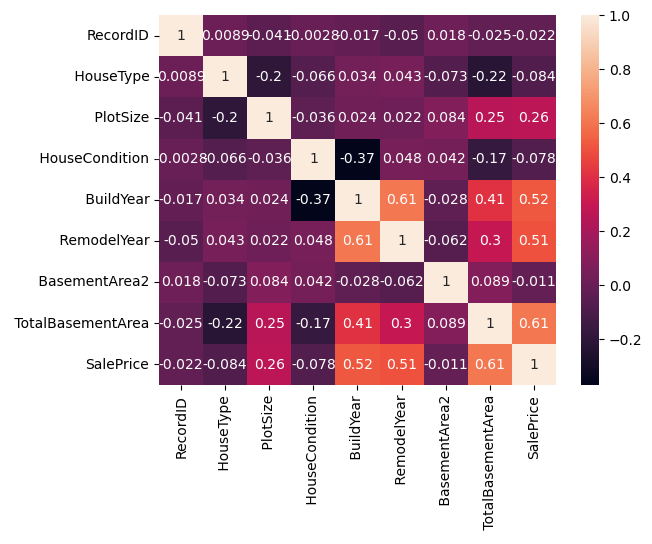

In [9]:
sns.heatmap(num_co, annot=True)
plt.show()

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RecordID            2919 non-null   int64  
 1    HouseType          2919 non-null   int64  
 2    ZoneType           2915 non-null   object 
 3    PlotSize           2919 non-null   int64  
 4    PlotShape          2919 non-null   object 
 5    BuildingType       2919 non-null   object 
 6    HouseCondition     2919 non-null   int64  
 7    BuildYear          2919 non-null   int64  
 8    RemodelYear        2919 non-null   int64  
 9    ExteriorType       2918 non-null   object 
 10   BasementArea2      2918 non-null   float64
 11   TotalBasementArea  2918 non-null   float64
 12  SalePrice           1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


In [8]:
data.describe()

,RecordID,HouseType,PlotSize,HouseCondition,BuildYear,RemodelYear,BasementArea2,TotalBasementArea,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


#### Basement area and construction year show the strongest relationship with sale price, indicating size and age as key pricing drivers.
#### Features with weak linear correlation were retained to allow non-linear models to capture hidden patterns.

## 5. DATA CLEANING


In [9]:
# 5.1 Clean column names
data.columns = data.columns.str.strip()


# 5.2 Drop ID column (no predictive value)
data.drop(columns="RecordID", inplace=True)

In [10]:
# 5.3 Missing Value Handling ....

data["TotalBasementArea"] = data["TotalBasementArea"].fillna(data["TotalBasementArea"].median())
data["BasementArea2"] = data["BasementArea2"].fillna(data["BasementArea2"].median())


data["ZoneType"] = data["ZoneType"].fillna(data["ZoneType"].mode().iloc[0])
data["ExteriorType"] = data["ExteriorType"].fillna(data["ExteriorType"].mode().iloc[0])


#### Median and mode imputation were used to preserve data distribution while minimizing the impact of outliers.

In [11]:
# 5.4 Outlier Detection (IQR Method) ....
# Outliers are analyzed but NOT removed

for col in ['HouseType', 'PlotSize', 'HouseCondition', 'BuildYear', 
            'RemodelYear', 'BasementArea2', 'TotalBasementArea', 'SalePrice']:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    ll = Q1 - 1.5 * IQR
    ul = Q3 + 1.5 * IQR

    outliers = data[(data[col] < ll) | (data[col] > ul)].shape[0]
    out_percent = outliers * 100 / data.shape[0]

    print(f"{col:<30} outlier_%: {round(out_percent,2)}")


HouseType                      outlier_%: 7.09
PlotSize                       outlier_%: 4.39
HouseCondition                 outlier_%: 8.63
BuildYear                      outlier_%: 0.31
RemodelYear                    outlier_%: 0.0
BasementArea2                  outlier_%: 11.89
TotalBasementArea              outlier_%: 4.18
SalePrice                      outlier_%: 2.09


#### Outliers were retained to ensure the model learns real-world price variability, especially for high-value properties.

## 6. FEATURE & TARGET SEPARATION


In [12]:
labeled_data = data[data["SalePrice"].notna()]
unlabeled_data = data[data["SalePrice"].isna()]

X = labeled_data.drop("SalePrice", axis=1)
y = labeled_data["SalePrice"]

#### Only records with known sale prices were used for training to ensure supervised learning without target leakage.

## 7. TRAIN–TEST SPLIT


In [13]:
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=40)

#### The dataset was split into training and testing sets to evaluate model performance on unseen data.

## 8. FEATURE ENCODING (ONE-HOT)


In [14]:
cat_col = xtrain.select_dtypes(include="object").columns

encoder = OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")

xtr_cat = encoder.fit_transform(xtrain[cat_col])
xts_cat = encoder.transform(xtest[cat_col])

xtr_cat_df = pd.DataFrame(xtr_cat,columns=encoder.get_feature_names_out(cat_col),index=xtrain.index)
xts_cat_df = pd.DataFrame(xts_cat,columns=encoder.get_feature_names_out(cat_col),index=xtest.index)

num_col = xtrain.select_dtypes(include="number").columns

xtr_final = pd.concat([xtrain[num_col], xtr_cat_df], axis=1)
xts_final = pd.concat([xtest[num_col], xts_cat_df], axis=1)



#### Categorical variables were one-hot encoded to convert them into a machine-learning-compatible numerical format.

## 9. FEATURE SCALING


In [15]:
scaler = StandardScaler()
xtr_scale = scaler.fit_transform(xtr_final)
xts_scale = scaler.transform(xts_final)


#### Feature scaling was applied to ensure uniform contribution of variables, especially for distance-based models.

## 10. MODEL BUILDING & EVALUATION


## -- Linear Regression --


In [16]:
lr = LinearRegression()
lr.fit(xtr_scale, ytrain)
lr_pred = lr.predict(xts_scale)

print("--Linear Regression--")
print("MAE :", mean_absolute_error(ytest, lr_pred))
print("R2  :", r2_score(ytest, lr_pred))
print("MSE :", mean_squared_error(ytest, lr_pred))
print("MAPE:", mean_absolute_percentage_error(ytest, lr_pred))


--Linear Regression--
MAE : 29409.677635601263
R2  : 0.6345242104163475
MSE : 1886821100.8906467
MAPE: 0.1696286399115882


## -- Decision Tree Regressor --

In [17]:
dtr = DecisionTreeRegressor(random_state = 42)
dtr.fit(xtr_scale,ytrain)
dtr_pred = dtr.predict(xts_scale)


print("--DecisionTreeRegressor--")
print("MAE :", mean_absolute_error(ytest, dtr_pred))
print("R2  :", r2_score(ytest, dtr_pred))
print("MSE :", mean_squared_error(ytest, dtr_pred))
print("MAPE:", mean_absolute_percentage_error(ytest, dtr_pred))


--DecisionTreeRegressor--
MAE : 33413.010273972606
R2  : 0.4495011501754581
MSE : 2842029145.2089043
MAPE: 0.190691808147202


## --RandomForestRegressor--

In [18]:
rf = RandomForestRegressor(n_estimators = 450, random_state = 42)
rf.fit(xtr_scale,ytrain)
rf_pred = rf.predict(xts_scale)


print("--RandomForestRegressor--")
print("MAE :", mean_absolute_error(ytest, rf_pred))
print("R2  :", r2_score(ytest, rf_pred))
print("MSE :", mean_squared_error(ytest, rf_pred))
print("MAPE:", mean_absolute_percentage_error(ytest, rf_pred))


--RandomForestRegressor--
MAE : 21573.327526455025
R2  : 0.7784016397305302
MSE : 1144033268.4020429
MAPE: 0.12074836676330214


## --XGBRegressor--

In [19]:
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators = 120 , random_state = 42 ,max_depth=14, subsample=0.8,colsample_bytree=0.8)
xgb.fit(xtr_scale,ytrain)
xgb_pred = xgb.predict(xts_scale)

print("--XGBRegressor--")
print("MAE :", mean_absolute_error(ytest, xgb_pred))
print("R2  :", r2_score(ytest, xgb_pred))
print("MSE :", mean_squared_error(ytest, xgb_pred))
print("MAPE:", mean_absolute_percentage_error(ytest, xgb_pred))

--XGBRegressor--
MAE : 21962.089589576197
R2  : 0.8008950377730735
MSE : 1027907879.8893005
MAPE: 0.1241016377213812


## --svm--

In [20]:
svm = SVR(C=500000, gamma=0.03, epsilon=0.1)
svm.fit(xtr_scale,ytrain)
svm_pred =  svm.predict(xts_scale)


print("--svm--")
print("MAE :", mean_absolute_error(ytest, svm_pred))
print("R2  :", r2_score(ytest, svm_pred))
print("MSE :", mean_squared_error(ytest, svm_pred))
print("MAPE:", mean_absolute_percentage_error(ytest, svm_pred))

--svm--
MAE : 23670.048104911377
R2  : 0.7528935026780661
MSE : 1275722678.7726402
MAPE: 0.13585275639418284


## FINAL CONCLUSION


#### XGBoost Regressor Performance

- Highest R² score  
- Very low MAE and MSE (close to Random Forest)  
- Better overall learning and generalization   

**Hence, XGBoost is recommended for deployment in real-world house price pedict ition.
#     